## Making Smart Researcher Assistan 



✅ PDF analysis (RAG)
✅ Live web search (Tavily)
✅ Wikipedia lookup
✅ Math calculator
✅ Arxiv papers
✅ Summary + Sources
✅ Chat history

## Step 1 : Import Env 

In [42]:
from dotenv import load_dotenv 
load_dotenv()
import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")


## Step 2 : LLM

In [43]:
from langchain_groq import ChatGroq
llm = ChatGroq(model_name="llama-3.1-8b-instant", api_key=groq_api_key)
llm 

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001A2D3212FC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001A2F220B8C0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

## Build TOOLs 

In [44]:
from langchain_community.tools import TavilySearchResults, ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wikipedia = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
print(wikipedia.name)
tavily = TavilySearchResults(max_results=2,api_key=tavily_api_key)
tools = [tavily,wikipedia,arxiv]

arxiv
wikipedia


## Made one tool

In [45]:
from langchain_core.tools import tool
@tool
def math_calculator(expression: str) -> str:
    """Solve math problems: '25*4 + 10/2'"""
    try:
        result = eval(expression)
        return f"✅ {expression} = **{result}**"
    except:
        return "❌ Invalid math expression"

tools = [tavily,wikipedia,arxiv,math_calculator]

## LLM with Tools 

In [46]:
llm_with_tools = llm.bind_tools(tools)

## Message State

In [47]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph import add_messages
from typing import Annotated 
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]


## Funtion 

In [48]:
def tools_call(state:State): 
    llm_with_tools_local= llm.bind_tools(tools)
    return {"messages":llm_with_tools_local.invoke(state["messages"])}

## Create The Grap

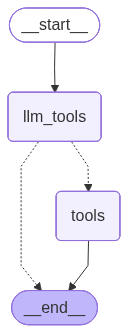

In [49]:
from IPython.display import Image,display 
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode,tools_condition
builder= StateGraph(State)
builder.add_node("llm_tools",tools_call)
builder.add_node("tools",ToolNode(tools))
builder.add_edge(START,"llm_tools")
builder.add_conditional_edges(
    "llm_tools",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    tools_condition,
)
builder.add_edge("tools",END)
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))



In [53]:
# Test the model
from langchain_core.messages import HumanMessage
question = input("Plz Enter Your Question : ")
messages = graph.invoke({"messages":[HumanMessage(content=question)]})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

ok give latest paper on Ai Agents 
================================== Ai Message ==================================
Tool Calls:
  arxiv (46hafay0j)
 Call ID: 46hafay0j
  Args:
    query: AI Agents
================================= Tool Message =================================
Name: arxiv

Published: 2025-01-06
Title: Foundations of GenIR
Authors: Qingyao Ai, Jingtao Zhan, Yiqun Liu
Summary: The chapter discusses the foundational impact of modern generative AI models on information access (IA) systems. In contrast to traditional AI, the large-scale training and superior data modeling of generative AI models enable them to produce high-quality, human-like responses, which brings brand new opportunities for the development of IA paradigms. In this chapter, we identify and introduce 
